# Tiled clustering model
 
This example is similar as the example presented in Figure 1 in Covariate-moderated Empirical Bayes Matrix Factorization  Denault et al 2025  Matrix Factorization
 
**Model description:**


We simulate a matrix $Z=LF^t$  in which $  L $ (but not $  F $) depended on the
2-d locations of the data points. Specifically, we generated a
periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile
1, 2 or 3. For each data point $i$, we set
$\ell_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise
$\ell_{ik} = 0$. The $  F $ matrix, by contrast, was simulated from
a simple scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 +
\sum_{m=1}^M N(0, \sigma_m^2)$. We simulated homoskedastic noise with
$\tau_{ij} = 0.1$.
 

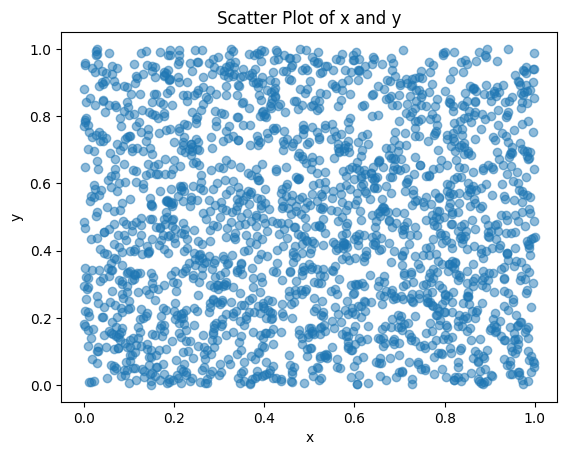

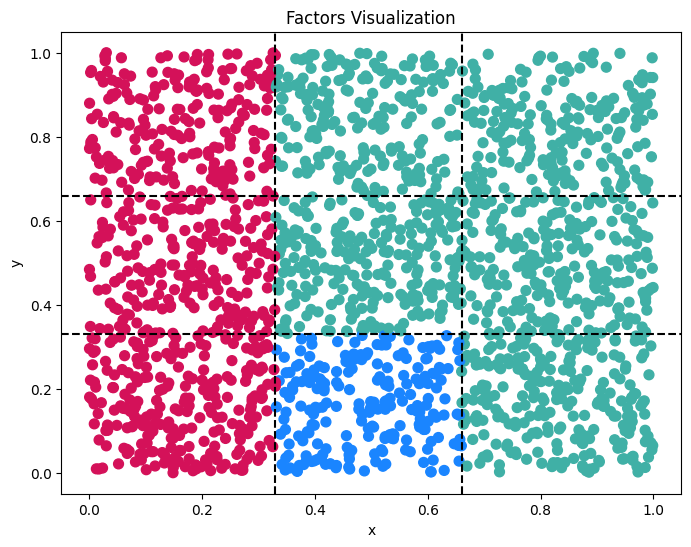

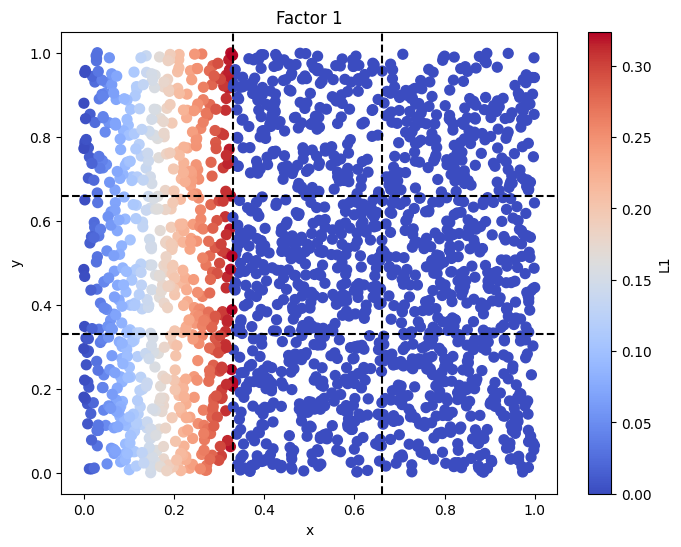

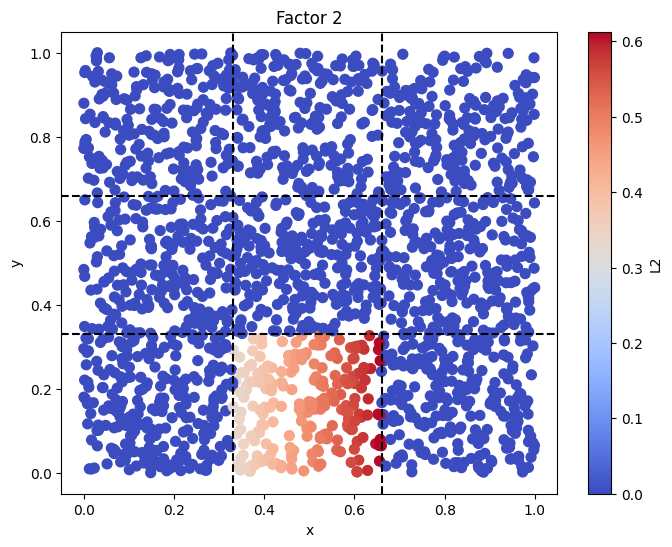

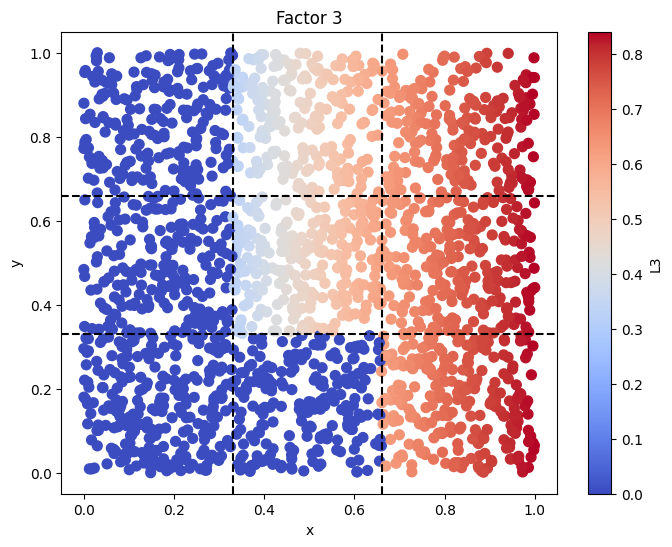

In [1]:
import torch
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(1)

# -------------------------
# 1) Random uniform data
# -------------------------
N = 2000
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N,2)

# Scatter of x vs y
plt.scatter(x.numpy(), y.numpy(), alpha=0.5)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Scatter Plot of x and y")
plt.show()

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------
M = 200
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # 0/1

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# -------------------------
# 3) Build L (N x 3) and factor labels
# -------------------------
L = torch.zeros(N, 3, dtype=torch.float32)

mask1 = x < 0.33
mask2 = (~mask1) & (x < 0.66) & (y < 0.33)
mask3 = ~(mask1 | mask2)

L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# -------------------------
# 4) Factor visualization
# -------------------------
colors = ["#D41159", "#1A85FF", "#40B0A6"]
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(8,6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=50)
for v in [0.33, 0.66]:
    plt.axhline(v, color="black", linestyle="--")
    plt.axvline(v, color="black", linestyle="--")
plt.title("Factors Visualization")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# -------------------------
# 5) Individual factor plots (L1, L2, L3 as color)
# -------------------------
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()

# -------------------------
# 6) Generate Z = L @ f + noise
# -------------------------
Z = L @ f + torch.randn(N, M) #* 2.5  # (N, M)


Fitting the model without account for the 2d side information

In [ ]:
from cebmf_torch import cEBMF
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(30)

tensor(-2736.1907)
6004.62109375
tensor(-3268.4304)
tensor(-2748.5396)
3726.33740234375
tensor(-977.7979)
tensor(-2801.0483)
3777.234619140625
tensor(-976.1863)
tensor(-2842.8203)
3386.9482421875
tensor(-544.1279)
tensor(-2844.1504)
3381.3369140625
tensor(-537.1865)
tensor(-2759.9263)
5999.486328125
tensor(-3239.5601)
tensor(-2762.2852)
3691.16259765625
tensor(-928.8774)
tensor(-2901.8645)
3792.664306640625
tensor(-890.7998)
tensor(-3109.8567)
3454.2919921875
tensor(-344.4353)
tensor(-3104.7246)
3443.7939453125
tensor(-339.0693)
tensor(-2759.6592)
5995.11279296875
tensor(-3235.4536)
tensor(-2769.7317)
3693.907470703125
tensor(-924.1758)
tensor(-2931.5081)
3812.26123046875
tensor(-880.7532)
tensor(-3256.7021)
3521.49072265625
tensor(-264.7886)
tensor(-3254.4106)
3502.373046875
tensor(-247.9624)
tensor(-2758.0859)
5991.76513671875
tensor(-3233.6792)
tensor(-2778.1738)
3701.018798828125
tensor(-922.8450)
tensor(-2955.9443)
3833.0322265625
tensor(-877.0879)
tensor(-3374.0273)
3582.15234375

Fitting the cEBMF model


Here we store the side information for the rows $L$ in the matrix $X$ that we pass in argument X_l (covariate for L)

In [3]:
mycebmf1=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" ) 
mycebmf1.initialise_factors()
mycebmf1.fit(3)

[CGB] Epoch 10/50, Loss=2.9940, mu2=-0.153, sigma2=6.664
[CGB] Epoch 20/50, Loss=2.9589, mu2=-0.309, sigma2=6.218
[CGB] Epoch 30/50, Loss=2.9385, mu2=-0.469, sigma2=6.430
[CGB] Epoch 40/50, Loss=2.9076, mu2=-0.632, sigma2=5.824
[CGB] Epoch 50/50, Loss=2.8855, mu2=-0.796, sigma2=5.663
tensor(-2862.0598)
4992.65234375
tensor(-2130.5925)
[CGB] Epoch 10/50, Loss=1.7823, mu2=-0.117, sigma2=5.101
[CGB] Epoch 20/50, Loss=1.7158, mu2=-0.228, sigma2=3.905
[CGB] Epoch 30/50, Loss=1.6936, mu2=-0.355, sigma2=4.320
[CGB] Epoch 40/50, Loss=1.6833, mu2=-0.491, sigma2=3.618
[CGB] Epoch 50/50, Loss=1.6787, mu2=-0.635, sigma2=4.291
tensor(-2909.0410)
3249.312744140625
tensor(-340.2717)
[CGB] Epoch 10/50, Loss=1.9266, mu2=0.128, sigma2=2.641
[CGB] Epoch 20/50, Loss=1.8441, mu2=0.276, sigma2=2.604
[CGB] Epoch 30/50, Loss=1.8151, mu2=0.436, sigma2=2.282
[CGB] Epoch 40/50, Loss=1.8002, mu2=0.604, sigma2=2.342
[CGB] Epoch 50/50, Loss=1.7825, mu2=0.780, sigma2=1.749
tensor(-2990.1277)
3379.782958984375
tensor

CEBMFResult(L=tensor([[-6.8412e+00, -1.2591e-08,  0.0000e+00],
        [-1.6878e-04,  0.0000e+00,  2.0226e+00],
        [-1.8803e+00,  0.0000e+00, -1.7336e-05],
        ...,
        [-6.4483e+00,  0.0000e+00,  0.0000e+00],
        [-4.0543e-05,  1.3525e-05,  2.4705e+00],
        [-2.4842e-06,  3.2239e-05,  1.5944e+00]]), F=tensor([[-1.3543e-01,  1.5781e-01, -1.1537e-01],
        [ 1.6586e-01,  1.5698e-01,  2.8796e-03],
        [-4.6814e-04, -1.0359e-03,  4.9722e-02],
        [-5.5637e-02,  1.2959e-01,  9.5095e-02],
        [ 1.1870e-05, -3.8423e-02,  8.8662e-02],
        [ 1.0064e-03,  2.8352e-03, -3.8798e-05],
        [-2.3618e-05, -1.2662e-02, -1.2444e-03],
        [-1.9264e-01,  1.5827e-01,  9.2159e-03],
        [-2.7744e-05, -8.8031e-05, -1.1036e-01],
        [-8.5085e-02,  2.5424e-01,  1.3581e-02],
        [-1.0372e-01,  6.2998e-02,  1.8012e-01],
        [ 9.8239e-02,  1.3710e-01,  8.8677e-03],
        [-2.2007e-04, -6.3624e-04, -1.5449e-01],
        [ 9.8779e-04,  1.0872e-03,  1.

tensor(0.0087)
tensor(0.0057)


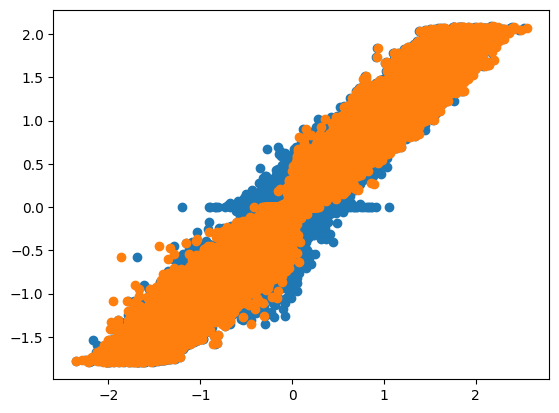

In [4]:
mycebmf._update_fitted_value()
mycebmf1._update_fitted_value()

plt.scatter(mycebmf.Y_fit,L@f)
plt.scatter(mycebmf1.Y_fit,L@f)
print(torch.mean((mycebmf.Y_fit-L@f).pow(2)))

print(torch.mean((mycebmf1.Y_fit-L@f).pow(2)))

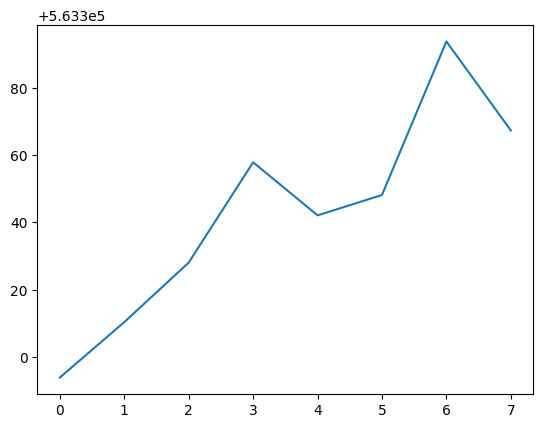

In [ ]:
plt.plot(mycebmf1.obj)
plt.plot(mycebmf.obj)

In [15]:
mycebmf1.fit(1)

[CGB] Epoch 10/50, Loss=2.9260, mu2=-0.153, sigma2=6.152
[CGB] Epoch 20/50, Loss=2.8881, mu2=-0.310, sigma2=6.410
[CGB] Epoch 30/50, Loss=2.8669, mu2=-0.470, sigma2=6.543
[CGB] Epoch 40/50, Loss=2.8464, mu2=-0.633, sigma2=5.852
[CGB] Epoch 50/50, Loss=2.8403, mu2=-0.799, sigma2=6.018
tensor(-2781.1978)
4872.35546875
tensor(-2091.1577)
[CGB] Epoch 10/50, Loss=1.5946, mu2=-0.110, sigma2=4.002
[CGB] Epoch 20/50, Loss=1.5458, mu2=-0.220, sigma2=4.159
[CGB] Epoch 30/50, Loss=1.5310, mu2=-0.348, sigma2=3.592
[CGB] Epoch 40/50, Loss=1.5263, mu2=-0.486, sigma2=3.752
[CGB] Epoch 50/50, Loss=1.5170, mu2=-0.633, sigma2=3.258
tensor(-2603.0901)
2938.34912109375
tensor(-335.2590)
[CGB] Epoch 10/50, Loss=1.2831, mu2=0.116, sigma2=1.249
[CGB] Epoch 20/50, Loss=1.2083, mu2=0.254, sigma2=1.323
[CGB] Epoch 30/50, Loss=1.1690, mu2=0.413, sigma2=1.346
[CGB] Epoch 40/50, Loss=1.1383, mu2=0.595, sigma2=0.936
[CGB] Epoch 50/50, Loss=1.1035, mu2=0.787, sigma2=0.696
tensor(-1713.4480)
1984.251220703125
tensor(

CEBMFResult(L=tensor([[-6.7285e+00, -3.1274e-07,  0.0000e+00],
        [-1.1145e-04,  0.0000e+00,  1.1947e+00],
        [-1.9845e+00,  0.0000e+00,  4.3868e-06],
        ...,
        [-6.3425e+00,  0.0000e+00,  0.0000e+00],
        [-3.4666e-05,  5.6003e-06,  1.4180e+00],
        [-1.0355e-05,  1.4966e-05,  1.0175e+00]]), F=tensor([[-1.3769e-01,  1.7381e-01, -1.9258e-01],
        [ 1.6864e-01,  1.7372e-01,  4.3977e-03],
        [-4.7549e-04, -1.1596e-03,  8.8126e-02],
        [-5.6569e-02,  1.4342e-01,  1.7343e-01],
        [ 1.2521e-05, -4.1617e-02,  1.4853e-01],
        [ 1.0274e-03,  3.1199e-03,  1.1071e-03],
        [-2.3315e-05, -1.4409e-02, -2.5788e-03],
        [-1.9581e-01,  1.7490e-01,  2.6174e-02],
        [-2.8582e-05, -4.8668e-05, -1.8631e-01],
        [-8.6542e-02,  2.8123e-01,  1.9320e-02],
        [-1.0541e-01,  6.9738e-02,  3.1003e-01],
        [ 9.9881e-02,  1.5161e-01,  1.1453e-02],
        [-2.2616e-04, -7.3414e-04, -2.6842e-01],
        [ 1.0030e-03,  1.2402e-03,  7.

In [7]:
mycebmf1.kl_f

tensor([-431.1676, -272.3100, -229.2466])

In [8]:
mycebmf1.kl_l

tensor([-2108.6245,  -334.8354,  -353.7109])

In [9]:
mycebmf.kl_l

tensor([-3.2302e+03, -9.2091e+02, -8.7076e+02, -2.7344e-02, -1.5625e-02])

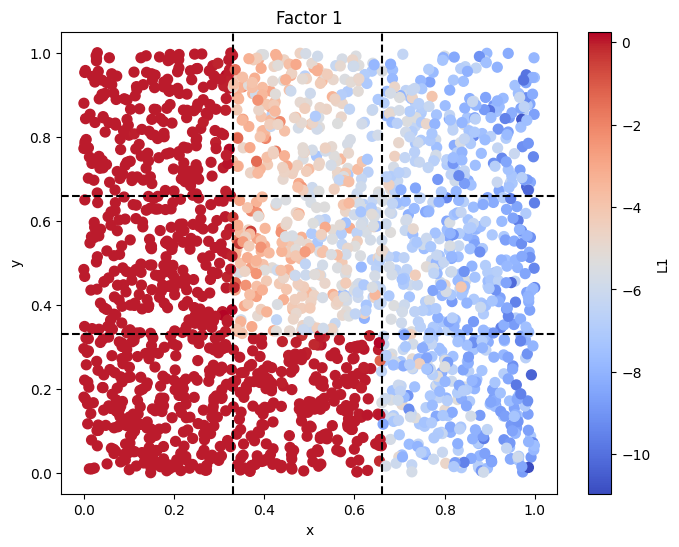

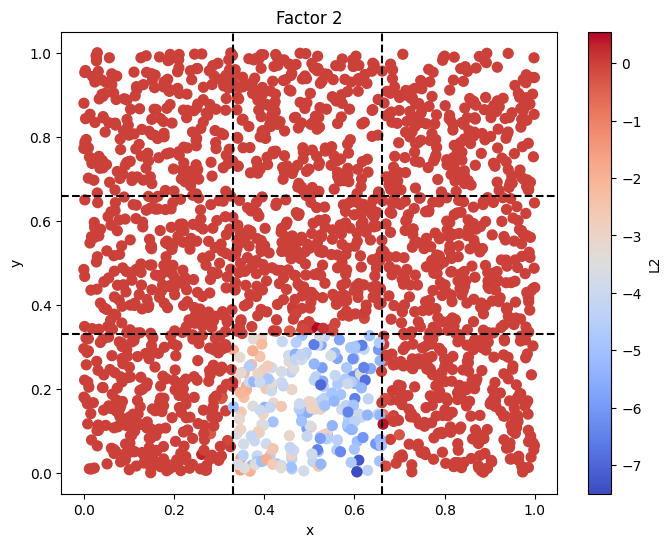

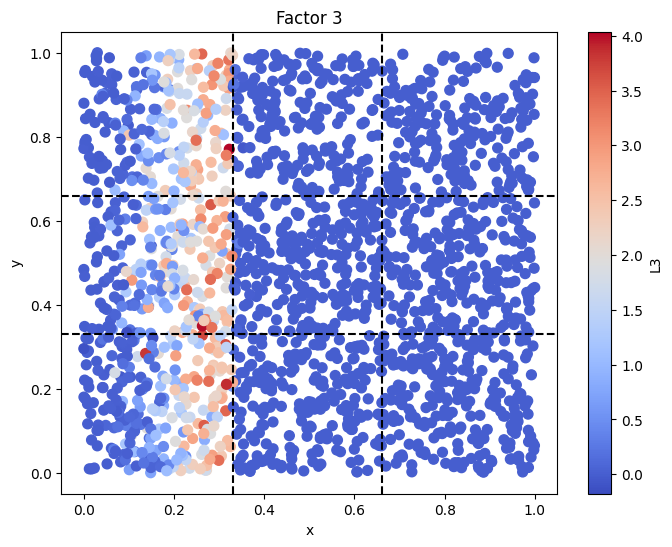

In [10]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf1.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


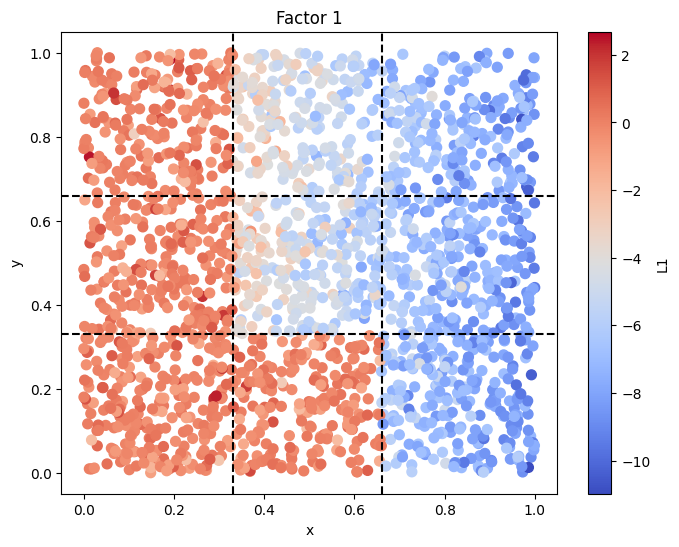

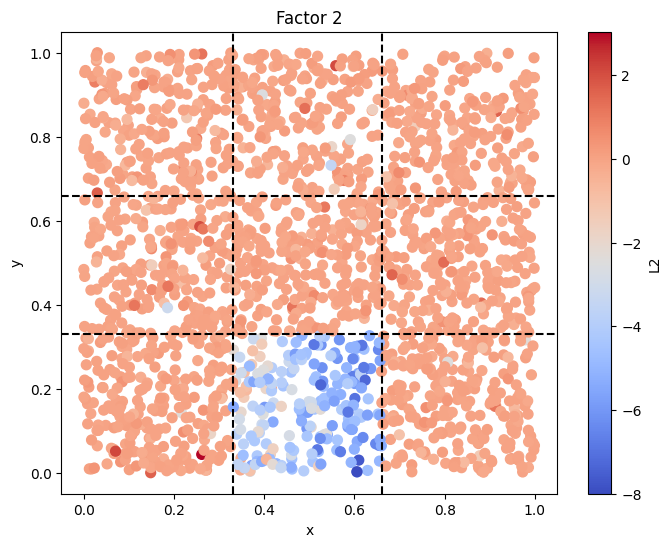

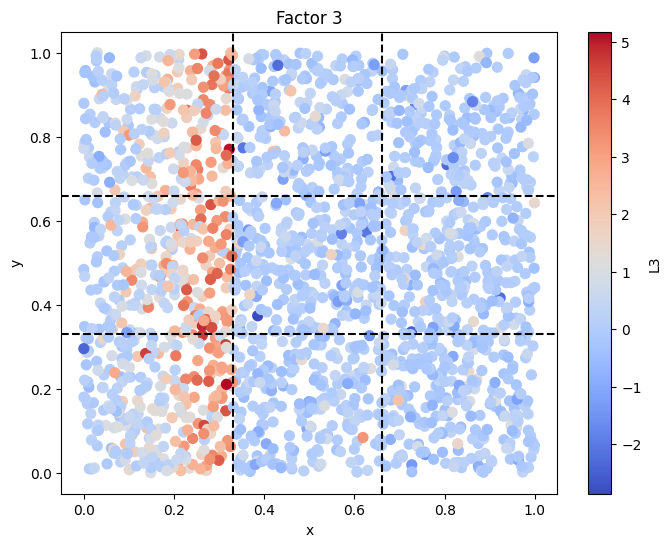

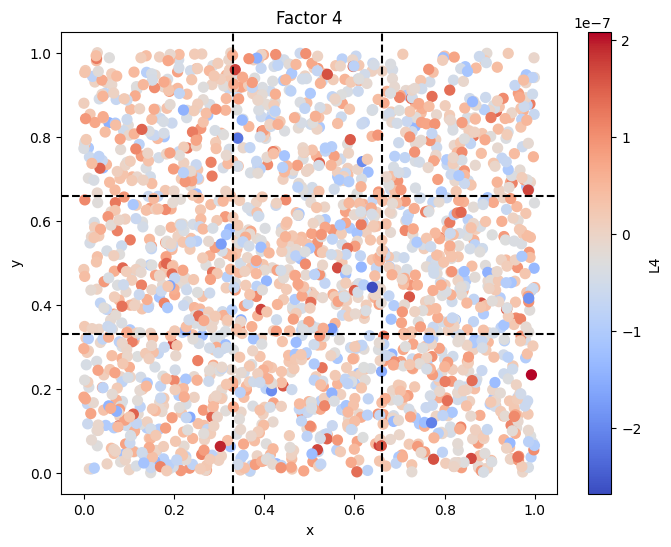

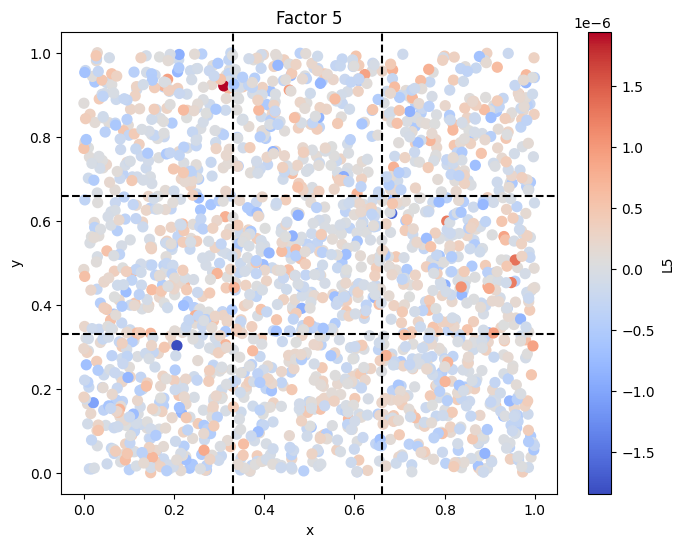

In [11]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()
